# SRMP Typology Spider Plots

This notebook creates spider/radar plots for the five SRMP typologies with inverted polarity for Mitigation Coupling and Equity Objective.

In [269]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Try to use a font that supports emoji/symbols
import matplotlib.font_manager as fm
try:
    # Try to find Apple Color Emoji or other emoji fonts
    emoji_fonts = [f.name for f in fm.fontManager.ttflist if 'emoji' in f.name.lower() or 'symbol' in f.name.lower()]
    if emoji_fonts:
        plt.rcParams['font.family'] = emoji_fonts[0]
        print(f"Using emoji font: {emoji_fonts[0]}")
    else:
        # Fall back to system fonts that might support symbols
        print("No emoji font found, using default fonts")
except:
    print("Could not configure emoji fonts")

Using emoji font: Apple Symbols


## Define SRMP Data

Based on Figure 4 and 5 from the document:
- **Fast Loop Properties**: Interruption Risk, Deployment Regionality, Operational Efficacy
- **Context Loop Triggers**: Mitigation Coupling (inverted), Equity Objective (inverted), Conflict Potential

**Note**: Mitigation Coupling and Equity Objective have been inverted so that low values = low risk for all metrics.

In [270]:
# Define the six properties - reordered to have Fast Loop Properties at top
# Start at -60 degrees from vertical and go clockwise
categories = [
    'Interruption\nRisk',           # -60 degrees (top left)
    'Deployment\nRegionality',      # 0 degrees (top right)
    'Operational\nEfficacy',        # 60 degrees (right)
    'Conflict\nPotential',          # 120 degrees (bottom right)
    'Equity\nObjective\n(inverted)', # 180 degrees (bottom left)
    'Mitigation\nCoupling\n(inverted)' # 240 degrees (left)
]

# Icon versions for compact display - reordered to match
category_icons = [
    '⚠',  # Interruption Risk
    '◐',  # Deployment Regionality
    '⚙',  # Operational Efficacy
    '⚔',  # Conflict Potential
    '⚖',  # Equity Objective
    '⚯',  # Mitigation Coupling
]

# Full category descriptions for legend - organized by type
category_descriptions_fast = {
    '⚠': 'Interruption Risk',
    '◐': 'Deployment Regionality',
    '⚙': 'Operational Efficacy',
}

category_descriptions_context = {
    '⚔': 'Conflict Potential',
    '⚖': 'Equity Objective (inverted)',
    '⚯': 'Mitigation Coupling (inverted)',
}

# SRMP typologies data (scale: 1=low risk, 2=medium risk, 3=high risk)
# Reordered to match new category order: IR, DR, OE, CP, EO, MC
srmp_data = {
    'SRMP-a: Idealized': {
        'values': [1, 1, 1, 1, 1, 1],  # All low risk
        'color': '#2E7D32',  # Green
        'description': 'Best-case: Globally coordinated, technically proficient, time-limited',
        'subtitle': 'Idealized'
    },
    'SRMP-b: Imperfect Cooperation': {
        'values': [2, 2, 2, 2, 2, 2],  # All medium risk
        'color': '#F57C00',  # Orange
        'description': 'Muddle-through: Flawed global framework with implementation gaps',
        'subtitle': 'Imperfect'
    },
    'SRMP-c: Conflict': {
        'values': [3, 3, 2, 3, 2, 2],  # High IR, DR, CP; Med OE, EO, MC
        'color': '#C62828',  # Red
        'description': 'High-risk: Unilateral/regional, geopolitical tool',
        'subtitle': 'Conflict'
    },
    'SRMP-d: Fragmented': {
        'values': [2, 3, 1, 2, 3, 2],  # Med IR, CP, MC; High DR, EO; Low OE
        'color': '#6A1B9A',  # Purple
        'description': 'Inequality-driven: Coalition-optimized, externalizing risks',
        'subtitle': 'Free Rider'
    },
    'SRMP-e: Moral Hazard': {
        'values': [1, 1, 1, 1, 2, 3],  # Low IR, DR, OE, CP; Med EO; High MC
        'color': '#0277BD',  # Blue
        'description': 'Ultimate moral hazard: Technically successful but substitutes mitigation',
        'subtitle': 'Moral Hazard'
    }
}

# Convert to DataFrame for easier manipulation
df = pd.DataFrame({
    name: data['values'] 
    for name, data in srmp_data.items()
}, index=categories)

print("SRMP Data Matrix (reordered):")
print(df)
print("\nFast Loop Properties:")
for icon, desc in category_descriptions_fast.items():
    print(f"{icon} = {desc}")
print("\nContext Loop Triggers:")
for icon, desc in category_descriptions_context.items():
    print(f"{icon} = {desc}")

SRMP Data Matrix (reordered):
                                  SRMP-a: Idealized  \
Interruption\nRisk                                1   
Deployment\nRegionality                           1   
Operational\nEfficacy                             1   
Conflict\nPotential                               1   
Equity\nObjective\n(inverted)                     1   
Mitigation\nCoupling\n(inverted)                  1   

                                  SRMP-b: Imperfect Cooperation  \
Interruption\nRisk                                            2   
Deployment\nRegionality                                       2   
Operational\nEfficacy                                         2   
Conflict\nPotential                                           2   
Equity\nObjective\n(inverted)                                 2   
Mitigation\nCoupling\n(inverted)                              2   

                                  SRMP-c: Conflict  SRMP-d: Fragmented  \
Interruption\nRisk                      

## Helper Function for Radar Charts

In [271]:
def radar_chart(ax, categories, values, color, title='', fill_alpha=0.25, use_icons=False, subtitle=''):
    """
    Create a radar/spider chart on the given axes.
    
    Parameters:
    -----------
    ax : matplotlib axes
        The axes to plot on
    categories : list
        List of category names or icons
    values : list
        List of values for each category
    color : str
        Color for the plot
    title : str
        Title for the chart (placed in center)
    fill_alpha : float
        Alpha value for fill
    use_icons : bool
        If True, use category_icons instead of full category names
    subtitle : str
        Subtitle to display below the title in colored text
    """
    N = len(categories)
    
    # Compute angle for each axis - start at -60 degrees from vertical
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    values = values + values[:1]  # Complete the circle
    angles += angles[:1]
    
    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=title)
    ax.fill(angles, values, alpha=fill_alpha, color=color)
    
    # Fix axis to go in the right order and start at -60 degrees from vertical
    ax.set_theta_offset(np.pi / 2 + np.pi / 3)  # 90 degrees + 60 degrees
    ax.set_theta_direction(-1)
    
    # Add background shading for bottom half (context loop triggers)
    # The dividing line should be between categories 3 and 4 (between OE and CP)
    # and between categories 0 and 5 (between IR and MC)
    # This is at angles π/6 and 7π/6 (30 degrees and 210 degrees)
    theta_bottom = np.linspace(-np.pi/6, -7*np.pi/6, 100)
    r_bottom = np.ones_like(theta_bottom) * 3
    ax.fill_between(theta_bottom, 0, r_bottom, alpha=0.08, color='black', zorder=0)
    
    # Draw axis lines for each angle and label
    ax.set_xticks(angles[:-1])
    if use_icons:
        # Use larger size for icons and allow matplotlib to use fallback fonts
        ax.set_xticklabels(category_icons, size=18, weight='normal')
        # Set font properties to help with rendering
        for label in ax.get_xticklabels():
            label.set_fontfamily('DejaVu Sans')
    else:
        ax.set_xticklabels(categories, size=8)
    
    # Set y-axis limits and labels
    ax.set_ylim(0, 3)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(['Low', 'Med', 'High'], size=10, color='gray')
    ax.set_rlabel_position(-30)
    
    # Manually rotate the radial tick labels
    for label in ax.get_yticklabels():
        label.set_rotation(-30)
    
    # Add grid - this will draw both radial lines and circular gridlines
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
    
    # Ensure radial lines are visible for each category
    ax.set_rgrids([1, 2, 3], angle=-30, labels=['Low', 'Med', 'High'], 
                  fontsize=10, color='gray')
    
    # Add horizontal dividing line between Fast Loop and Context Loop
    # The line should go from angle π/6 to 7π/6 (between the categories)
    ax.plot([-np.pi/6, -7*np.pi/6], [3.1, 3.1], 'k-', linewidth=1.5, alpha=0.6, zorder=5)
    
    # Add labels for Fast Loop Properties and Context Loop Triggers
    ax.text(-7*np.pi/6-np.pi/20, 2, 'Fast Loop', ha='center', va='bottom',
            size=10, weight='bold', color='black', style='italic')
    ax.text(-7*np.pi/6+np.pi/20, 2, 'Context Loop', ha='center', va='bottom',
            size=10, weight='bold', color='black', style='italic')
    
    # Add arrow vector at 30 degrees from vertical showing "increasing risk"
    # In polar coordinates: theta is angle, r is radius
    # 30 degrees clockwise from vertical = 30 degrees in our coordinate system
    arrow_angle = np.radians(30)  # 30 degrees clockwise from vertical
    arrow_start_r = 0.3
    arrow_end_r = 2.5
    
    ax.annotate('', xy=(arrow_angle, arrow_end_r), xytext=(arrow_angle, arrow_start_r),
                arrowprops=dict(arrowstyle='->', lw=2, color='darkred', alpha=0.6))
    
    # Add "Increasing Risk" label along the arrow
    ax.text(arrow_angle, arrow_end_r + 0.3, 'Increasing\nRisk', 
            ha='center', va='bottom', size=10, color='darkred', 
            style='italic', weight='bold', rotation=-60)
    
    # Add title in the center of the plot with white box
    if title:
        ax.text(0, 0, title, ha='center', va='center', 
                size=10, weight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor=color, alpha=0.9, linewidth=1.5),
                transform=ax.transData, zorder=10)
        
        # Add subtitle below title in colored text (no box)
        if subtitle:
            ax.text(0, -0.4, subtitle, ha='center', va='top', 
                    size=10, weight='normal', color=color,
                    style='italic',
                    transform=ax.transData, zorder=9)
    
    return ax

## Create Individual Spider Plots (Top Row)

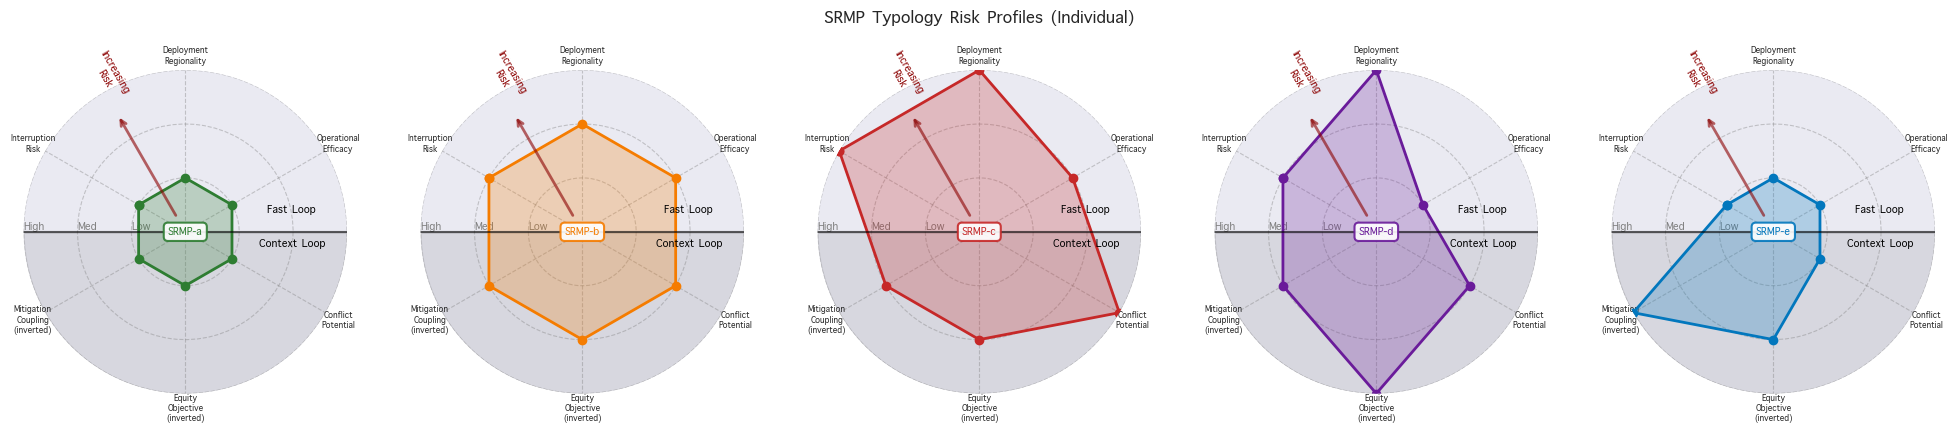

In [272]:
# Create figure with 5 subplots in a row
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw=dict(projection='polar'))
fig.suptitle('SRMP Typology Risk Profiles (Individual)', fontsize=16, weight='bold', y=1.02)

# Plot each SRMP
for idx, (name, data) in enumerate(srmp_data.items()):
    radar_chart(
        axes[idx],
        categories,
        data['values'],
        data['color'],
        title=name.split(':')[0]  # Just the SRMP code
    )

plt.tight_layout()
plt.savefig('srmp_individual_spider_plots.png', dpi=300, bbox_inches='tight')
plt.show()



## Create Combined Spider Plot (Bottom)

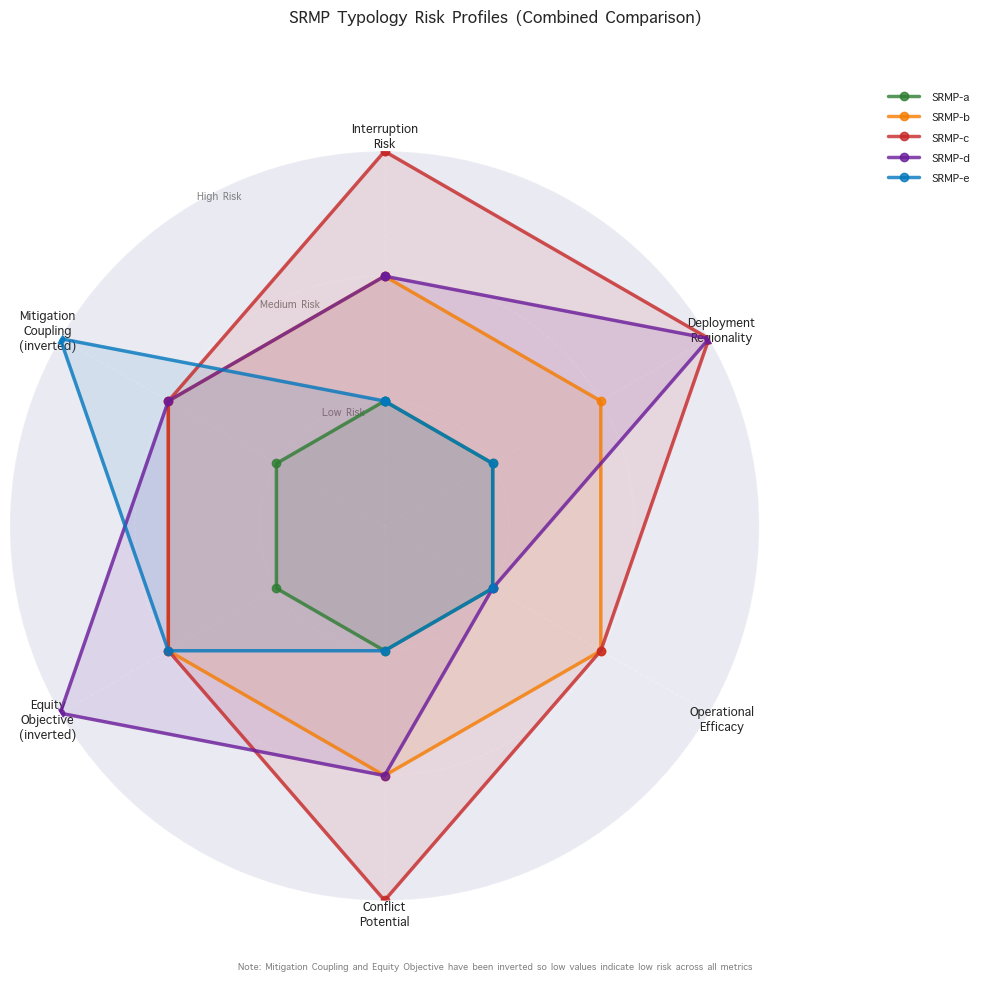

In [273]:
# Create a larger combined plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
fig.suptitle('SRMP Typology Risk Profiles (Combined Comparison)', 
             fontsize=16, weight='bold', y=0.98)

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Plot all SRMPs on the same chart
for name, data in srmp_data.items():
    values = data['values'] + data['values'][:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=data['color'], 
            label=name.split(':')[0], alpha=0.8)
    ax.fill(angles, values, alpha=0.1, color=data['color'])

# Configure axes
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 3)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Low Risk', 'Medium Risk', 'High Risk'], size=10, color='gray')
ax.set_rlabel_position(-30)

# Manually rotate the radial tick labels
for label in ax.get_yticklabels():
    label.set_rotation(-30)

ax.grid(True, linestyle='--', alpha=0.3)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

# Add note about inversions
fig.text(0.5, 0.02, 
         'Note: Mitigation Coupling and Equity Objective have been inverted so low values indicate low risk across all metrics',
         ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('srmp_combined_spider_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## Create Final Composite Figure (Top Row + Bottom Combined)

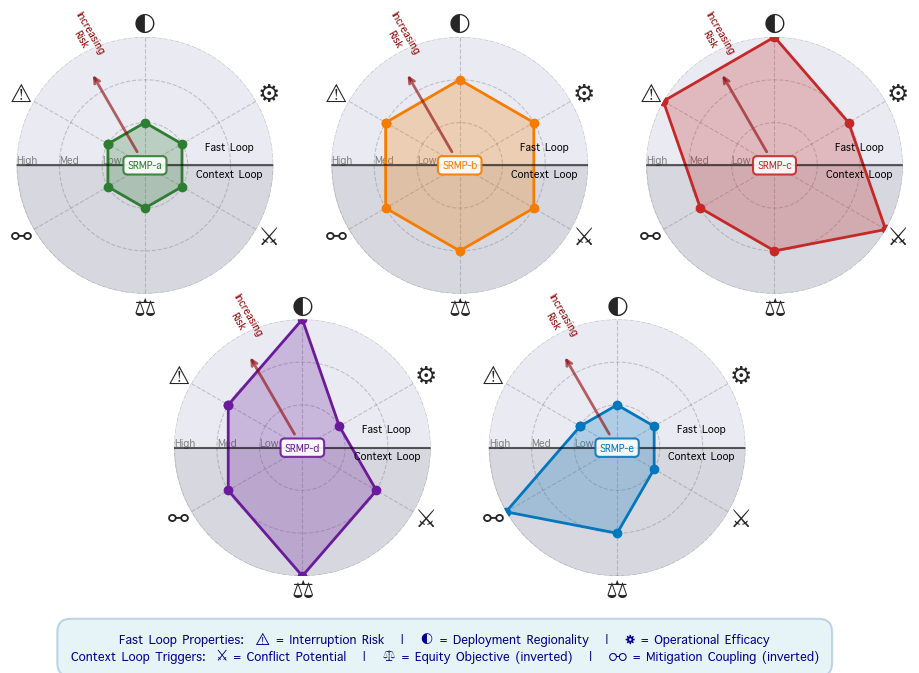

In [276]:
# Create composite figure with 3-2 layout and icon legend
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 6, hspace=0.1, wspace=0.1, top=0.92, bottom=0.15)

# Add main title

# Top row - 3 plots (SRMP-a, SRMP-b, SRMP-c) - columns 0, 2, 4
srmp_list = list(srmp_data.items())
top_positions = [0, 2, 4]
for idx, col_pos in enumerate(top_positions):
    name, data = srmp_list[idx]
    ax = fig.add_subplot(gs[0, col_pos:col_pos+2], projection='polar')
    # Use just the SRMP code for compact labels
    compact_label = name.split(':')[0]
    radar_chart(
        ax,
        categories,
        data['values'],
        data['color'],
        title=compact_label,
        use_icons=True,
        subtitle=data['subtitle']
    )

# Bottom row - 2 plots offset (SRMP-d, SRMP-e) - columns 1, 3
bottom_positions = [1, 3]
for idx, col_pos in enumerate(bottom_positions):
    name, data = srmp_list[3 + idx]
    ax = fig.add_subplot(gs[1, col_pos:col_pos+2], projection='polar')
    # Use just the SRMP code for compact labels
    compact_label = name.split(':')[0]
    radar_chart(
        ax,
        categories,
        data['values'],
        data['color'],
        title=compact_label,
        use_icons=True,
        subtitle=data['subtitle']
    )

# Add icon legend at the bottom with headers for each category type
fast_loop_text = "Fast Loop Properties:  "
for icon, desc in category_descriptions_fast.items():
    fast_loop_text += f"{icon} = {desc}   |   "
fast_loop_text = fast_loop_text.rstrip("   |   ")

context_loop_text = "Context Loop Triggers:  "
for icon, desc in category_descriptions_context.items():
    context_loop_text += f"{icon} = {desc}   |   "
context_loop_text = context_loop_text.rstrip("   |   ")

legend_text = fast_loop_text + "\n" + context_loop_text

fig.text(0.5, 0.03, legend_text,
         ha='center', fontsize=12, weight='normal', color='darkblue',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', 
                  edgecolor='steelblue', alpha=0.3, linewidth=1.5))



plt.savefig('figure5_srmp_spider_plots_composite.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary Table of SRMP Properties

In [275]:
# Create summary table
summary_df = df.T
summary_df['Description'] = [data['description'] for data in srmp_data.values()]
summary_df['Color'] = [data['color'] for data in srmp_data.values()]

print("\nSRMP Summary Table:")
print("=" * 100)
print(summary_df.to_string())
print("\n" + "=" * 100)
print("Risk Scale: 1 = Low Risk, 2 = Medium Risk, 3 = High Risk")
print("Note: Mitigation Coupling and Equity Objective have been inverted for consistency")


SRMP Summary Table:
                               Interruption\nRisk  Deployment\nRegionality  Operational\nEfficacy  Conflict\nPotential  Equity\nObjective\n(inverted)  Mitigation\nCoupling\n(inverted)                                                               Description    Color
SRMP-a: Idealized                               1                        1                      1                    1                              1                                 1     Best-case: Globally coordinated, technically proficient, time-limited  #2E7D32
SRMP-b: Imperfect Cooperation                   2                        2                      2                    2                              2                                 2          Muddle-through: Flawed global framework with implementation gaps  #F57C00
SRMP-c: Conflict                                3                        3                      2                    3                              2                             